# Deployment-Stability Plot (Pre → Deploy → Post)

This notebook plots the **ICML-style** figure you described:
- **x-axis:** `step`
- **top panel:** counterfactual fairness gap (default: `gFair_max = max(|gTE_gap|, gCal_max, gMin)`)
- **bottom panel:** utility (default: `ndcg@10`)
- **Pre / Deploy / Post** shown via shaded regions + boundary lines
- Supports **multiple seeds/files** per method and plots **mean ± std**

Edit the **INPUTS** cell below (CSV paths/globs + metric names) and run it to refresh the plot.


In [1]:
# If you re-run cells often, it's convenient to autoreload local modules (optional)
%matplotlib inline


In [89]:
import os
import glob
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 你指定的颜色 ---
# Base / Reference (浅粉): #f6cae5
# COPF / Main (深玫红): #cc4a74
COLOR_PALETTE = {
    "light": "#f6cae5",
    "dark":  "#cc4a74"
}

PHASE_ORDER = ["pre", "deploy", "post"]

# --- 全局字体设置 (可根据需要调整) ---
plt.rcParams.update({
    'font.size': 14,          # 全局默认字体大小
    'axes.titlesize': 16,     # 子图标题大小
    'axes.labelsize': 16,     # 轴标签大小
    'xtick.labelsize': 14,    # x轴刻度标签大小
    'ytick.labelsize': 14,    # y轴刻度标签大小
    'legend.fontsize': 14,    # 图例字体大小
    'figure.titlesize': 18    # 整个画布标题大小
})


def read_one_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "step" not in df.columns:
        raise ValueError(f"Missing 'step' column in {path}")
    df["step"] = pd.to_numeric(df["step"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["step"]).copy()
    df["step"] = df["step"].astype(int)

    if "phase" in df.columns:
        df["phase"] = df["phase"].astype(str).str.strip().str.lower()
        df.loc[df["phase"].str.startswith("pre"), "phase"] = "pre"
        df.loc[df["phase"].str.startswith("dep"), "phase"] = "deploy"
        df.loc[df["phase"].str.startswith("pos"), "phase"] = "post"
    return df

def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Adds gFair_max = max(|gTE_gap|, gCal_max/gCal_max_all, gMin) when possible."""
    cols = df.columns
    components = []

    if "gTE_gap" in cols:
        components.append(df["gTE_gap"].astype(float).abs().to_numpy())

    if "gCal_max" in cols:
        components.append(df["gCal_max"].astype(float).to_numpy())
    elif "gCal_max_all" in cols:
        components.append(df["gCal_max_all"].astype(float).to_numpy())

    if "gMin" in cols:
        components.append(df["gMin"].astype(float).to_numpy())

    if components:
        df["gFair_max"] = np.nanmax(np.stack(components, axis=0), axis=0)
    return df

def infer_default_metric(df: pd.DataFrame, kind: str) -> str:
    cols = set(df.columns)
    if kind == "fair":
        for c in ["gFair_max", "gTE_gap", "gCal_max", "gCal_max_all", "gMin"]:
            if c in cols:
                return c
        raise ValueError("No known fairness metric found (need gTE_gap / gCal_max / gCal_max_all / gMin).")
    else:
        for c in ["ndcg@10", "mrr", "hits@10", "ap"]:
            if c in cols:
                return c
        raise ValueError("No known utility metric found (ndcg@10 / mrr / hits@10 / ap).")

def phase_spans(df: pd.DataFrame) -> List[Tuple[int, int, str]]:
    if "phase" not in df.columns:
        return []
    spans = []
    for ph in PHASE_ORDER:
        sub = df[df["phase"] == ph]
        if len(sub) == 0:
            continue
        spans.append((int(sub["step"].min()), int(sub["step"].max()), ph))
    spans.sort(key=lambda x: x[0])
    return spans

def aggregate(df: pd.DataFrame, ycol: str) -> pd.DataFrame:
    if ycol not in df.columns:
        raise ValueError(f"Column '{ycol}' not found. Available: {list(df.columns)}")
    out = (
        df.groupby("step", as_index=False)[ycol]
          .agg(mean="mean", std="std", n="count")
          .sort_values("step")
          .reset_index(drop=True)
    )
    return out

def smooth_series(x: np.ndarray, w: int) -> np.ndarray:
    if w <= 1:
        return x
    return pd.Series(x).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

@dataclass
class RunSpec:
    label: str
    pattern: str  # glob pattern

def expand_specs(specs: List[RunSpec]) -> Dict[str, List[str]]:
    out = {}
    for s in specs:
        files = sorted(glob.glob(s.pattern, recursive=True))
        if not files:
            raise FileNotFoundError(f"No files matched: {s.pattern}")
        out[s.label] = files
    return out

def load_run(files: List[str]) -> pd.DataFrame:
    dfs = []
    for i, f in enumerate(files):
        df = read_one_csv(f)
        df = add_derived_metrics(df)
        df["_file_id"] = i
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def pick_best_spans(run_frames: Dict[str, pd.DataFrame]) -> List[Tuple[int, int, str]]:
    def score(spans):
        phases = {p for _, _, p in spans}
        return sum(ph in phases for ph in PHASE_ORDER)

    best, best_spans = -1, []
    for _, df in run_frames.items():
        spans = phase_spans(df)
        sc = score(spans)
        if sc > best:
            best, best_spans = sc, spans
    return best_spans

def plot_deploy_stability(
    specs: List[RunSpec],
    fair: str = "auto",
    util: str = "auto",
    smooth: int = 1,
    drift: bool = False,
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (10, 8), # 加大画布尺寸
):
    """
    Main plotting function with custom pink colors.
    Colors: #cc4a74 (Dark) for COPF, #f6cae5 (Light) for Baseline.
    """
    files_map = expand_specs(specs)
    run_frames = {label: load_run(files) for label, files in files_map.items()}

    # Choose default columns
    first_df = next(iter(run_frames.values()))
    fair_col = infer_default_metric(first_df, "fair") if fair == "auto" else fair
    util_col = infer_default_metric(first_df, "util") if util == "auto" else util

    # Optional drift calculation
    if drift:
        for label, df in run_frames.items():
            if "phase" not in df.columns:
                raise ValueError("drift=True requires a 'phase' column.")
            # Resolve column again per df to be safe
            fc = fair_col if fair_col in df.columns else infer_default_metric(df, "fair")
            
            pre = df[df["phase"] == "pre"]
            if len(pre) == 0:
                raise ValueError(f"No pre rows found for run: {label}")
            pre_mean = float(pre[fc].astype(float).mean())
            
            # overwrite or add derived col
            df[fc] = (df[fc].astype(float) - pre_mean).abs()

    spans = pick_best_spans(run_frames)

    fig, (ax_f, ax_u) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(height_ratios=[2.0, 1.4], hspace=0.15) # 稍微增加子图间距
    )

    # Background shading
    if spans:
        for a, b, ph in spans:
            ax_f.axvspan(a, b, color="#ffffff", alpha=0.3, lw=0)
            ax_u.axvspan(a, b, color="#ffffff", alpha=0.3, lw=0)

        for ph in ["deploy", "post"]:
            mins = [a for (a, _, p) in spans if p == ph]
            if mins:
                t = min(mins)
                ax_f.axvline(t, linestyle=":", linewidth=1.5, color="gray") # 加粗分割线
                ax_u.axvline(t, linestyle=":", linewidth=1.5, color="gray")

        for a, b, ph in spans:
            ax_f.text(
                (a + b) / 2, 1.02, ph.upper(),
                transform=ax_f.get_xaxis_transform(),
                ha="center", va="bottom", 
                fontsize=14, fontweight="bold", color="#333333" # 调大 Phase Label 字体
            )

    # Plot each run
    for s in specs:
        label = s.label
        df = run_frames[label]

        fc = fair_col if fair_col in df.columns else infer_default_metric(df, "fair")
        uc = util_col if util_col in df.columns else infer_default_metric(df, "util")

        fair_agg = aggregate(df, fc)
        util_agg = aggregate(df, uc)

        x = fair_agg["step"].to_numpy()
        y = smooth_series(fair_agg["mean"].to_numpy(dtype=float), smooth)
        y_std = fair_agg["std"].to_numpy(dtype=float)

        x2 = util_agg["step"].to_numpy()
        y2 = smooth_series(util_agg["mean"].to_numpy(dtype=float), smooth)
        y2_std = util_agg["std"].to_numpy(dtype=float)

        # Style & Color Logic
        label_lower = label.lower()
        is_copf = "copf" in label_lower
        
        if is_copf:
            color = COLOR_PALETTE["dark"]  # #cc4a74
            ls = "-"
            zorder = 10 
            label_text = label 
            lw = 3.0 # 加粗线条
        else:
            color = COLOR_PALETTE["light"] # #f6cae5
            ls = "--"
            zorder = 5
            label_text = label
            lw = 3.0 # 加粗线条

        # Fairness Plot
        ax_f.plot(x, y, linestyle=ls, linewidth=lw, color=color, label=label_text, zorder=zorder)
        if np.nanmax(y_std) > 0:
            lo = smooth_series((fair_agg["mean"] - fair_agg["std"]).to_numpy(dtype=float), smooth)
            hi = smooth_series((fair_agg["mean"] + fair_agg["std"]).to_numpy(dtype=float), smooth)
            ax_f.fill_between(x, lo, hi, color=color, alpha=0.15, zorder=zorder-1)

        # Utility Plot
        ax_u.plot(x2, y2, linestyle=ls, linewidth=lw, color=color, zorder=zorder)
        if np.nanmax(y2_std) > 0:
            lo2 = smooth_series((util_agg["mean"] - util_agg["std"]).to_numpy(dtype=float), smooth)
            hi2 = smooth_series((util_agg["mean"] + util_agg["std"]).to_numpy(dtype=float), smooth)
            ax_u.fill_between(x2, lo2, hi2, color=color, alpha=0.15, zorder=zorder-1)

    # Labels and Ticks - 显式设置大字体
    ax_f.set_ylabel(f"Δ {fair_col}" if drift else fair_col, fontsize=16, fontweight='bold', labelpad=10)
    ax_u.set_ylabel(util_col, fontsize=16, fontweight='bold', labelpad=10)
    ax_u.set_xlabel("Time Step", fontsize=16, fontweight='bold', labelpad=10)
    
    # 刻度字体
    ax_f.tick_params(axis='both', which='major', labelsize=14)
    ax_u.tick_params(axis='both', which='major', labelsize=14)

    # Zero line for fairness
    ax_f.axhline(0.0, linestyle="-", linewidth=1.0, color="#cccccc", zorder=0)

    # Legend - 显式设置大字体
    ax_f.legend(loc="upper left", frameon=True, fancybox=True, framealpha=0.9, fontsize=14)

    if title:
        fig.suptitle(title, y=0.99, fontsize=20, fontweight='bold')

    plt.tight_layout()
    plt.show()
    return run_frames

def preview_columns(pattern: str, n: int = 30):
    """Quickly inspect columns from the first matching file."""
    files = sorted(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError(f"No files matched: {pattern}")
    df = add_derived_metrics(read_one_csv(files[0]))
    print("First file:", files[0])
    print("Columns:\n", list(df.columns))
    display(df.head(n))

## INPUTS (edit this cell)

Set your **CSV glob patterns** below. Each pattern can match many seeds/runs (mean±std will be plotted).

Typical examples (adjust to your tree):
- `out/base_edgebank/**/metrics.csv`
- `out/copf_edgebank/**/metrics.csv`


In [131]:
# ====== EDIT THESE ======

# 1) Put your globs here (each should match multiple seeds if you have them)
SPECS = [
    RunSpec(label="edgebank (base)", pattern="/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113519/base/edgebank/seed43/opp_copf_metrics.csv"),
    RunSpec(label="edgebank + COPF", pattern="/data1/shengen/fairlink/out/batch_synth_bipartite_v1_20260119_113403/copf/edgebank/seed42/opp_copf_metrics.csv"),
]

# 2) Metrics to plot
FAIR_METRIC = "gTE_gap"   # recommended: gFair_max OR gTE_gap OR gCal_max
UTIL_METRIC = "ndcg@10"     # recommended: ndcg@10 OR mrr OR hits@10

# 3) Plot options
SMOOTH = 3                  # 1 = no smoothing
DRIFT = False               # True => plot |fair - pre_mean| drift
TITLE = "Synthetic"

# ====== END EDIT ======


## (Optional) Quick peek at a CSV

If you’re unsure about column names or whether `gFair_max` is computed, run the next cell.


In [10]:
# Pick one pattern to inspect
# preview_columns(SPECS[0].pattern)


## Plot
Run this cell each time you change `SPECS` / metrics.


/tmp/ipykernel_1781690/180022497.py:247: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(y_std) > 0:
/tmp/ipykernel_1781690/180022497.py:254: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(y2_std) > 0:
/tmp/ipykernel_1781690/180022497.py:247: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(y_std) > 0:
/tmp/ipykernel_1781690/180022497.py:254: RuntimeWarning: All-NaN slice encountered
  if np.nanmax(y2_std) > 0:
/tmp/ipykernel_1781690/180022497.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


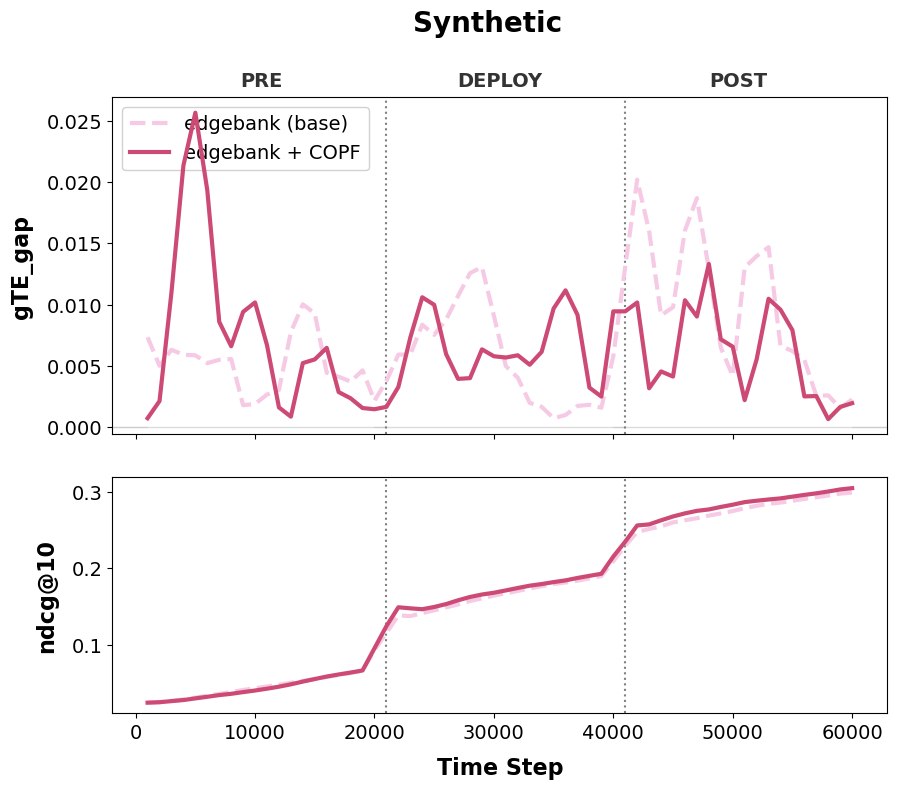

In [132]:
run_frames = plot_deploy_stability(
    SPECS,
    fair=FAIR_METRIC,
    util=UTIL_METRIC,
    smooth=SMOOTH,
    drift=DRIFT,
    title=TITLE,
)


## Notes on choosing the fairness metric

- **Best single-curve (robust):** `gFair_max = max(|gTE_gap|, gCal_max, gMin)`
- If you want the cleanest theoretical alignment:
  - **gTE:** `gTE_gap`
  - **gCal:** `gCal_max`
- For appendix diagnostics: plot `gTE_gap` and `gCal_max` separately.
